In [41]:
import pandas as pd
import numpy as np

sales = pd.read_csv('sales_pipeline.csv')
accounts = pd.read_csv('accounts.csv')
products = pd.read_csv('products.csv')
teams = pd.read_csv('sales_teams.csv')

# Convert dates
sales['engage_date'] = pd.to_datetime(sales['engage_date'])
sales['close_date'] = pd.to_datetime(sales['close_date'])

# Join everything into one master table
df = sales.merge(teams, on='sales_agent', how='left')
df = df.merge(accounts, on='account', how='left')
df = df.merge(products, on='product', how='left')

print("Master table shape:", df.shape)
print("\nNull check (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print("\nDate range:")
print("Engage:", df['engage_date'].min(), "to", df['engage_date'].max())
print("Close:", df['close_date'].min(), "to", df['close_date'].max())
print("\nRegional office distribution:")
print(df['regional_office'].value_counts())

Master table shape: (8800, 18)

Null check (top 10):
subsidiary_of       7508
close_value         2089
close_date          2089
series              1480
sales_price         1480
revenue             1425
year_established    1425
sector              1425
account             1425
employees           1425
dtype: int64

Date range:
Engage: 2016-10-20 00:00:00 to 2017-12-27 00:00:00
Close: 2017-03-01 00:00:00 to 2017-12-31 00:00:00

Regional office distribution:
regional_office
Central    3512
West       2997
East       2291
Name: count, dtype: int64


In [42]:
# Look at opportunities with missing account info
missing_account = df[df['account'].isnull()]
print("Rows with missing account:", len(missing_account))
print("\nDeal stage breakdown for missing-account rows:")
print(missing_account['deal_stage'].value_counts())
print("\nSample of missing-account rows (raw sales_pipeline only):")
print(sales[sales['account'].isnull()].head(5))

Rows with missing account: 1425

Deal stage breakdown for missing-account rows:
deal_stage
Engaging       1088
Prospecting     337
Name: count, dtype: int64

Sample of missing-account rows (raw sales_pipeline only):
   opportunity_id     sales_agent         product account deal_stage  \
9        HAXMC4IX  James Ascencio     MG Advanced     NaN   Engaging   
42       EG7OFLFR   Kami Bicknell       GTX Basic     NaN   Engaging   
44       OLVI7L8M    Cassey Cress          GTXPro     NaN   Engaging   
56       F5U1ACDD   Kami Bicknell  GTX Plus Basic     NaN   Engaging   
60       ZZY4516R   Hayden Neloms     MG Advanced     NaN   Engaging   

   engage_date close_date  close_value  
9   2016-11-03        NaT          NaN  
42  2016-11-14        NaT          NaN  
44  2016-11-16        NaT          NaN  
56  2016-11-19        NaT          NaN  
60  2016-11-20        NaT          NaN  


In [43]:
# Core KPI 1: Win Rate (only count CLOSED deals - Won or Lost, exclude open pipeline)
closed_deals = df[df['deal_stage'].isin(['Won', 'Lost'])]
win_rate = (closed_deals['deal_stage'] == 'Won').mean() * 100

# Core KPI 2: Average Deal Size (Won deals only)
avg_deal_size = df[df['deal_stage'] == 'Won']['close_value'].mean()

# Core KPI 3: Sales Cycle Time (days from engage to close, Won deals only)
won_deals = df[df['deal_stage'] == 'Won'].copy()
won_deals['cycle_days'] = (won_deals['close_date'] - won_deals['engage_date']).dt.days
avg_cycle_time = won_deals['cycle_days'].mean()

print("="*50)
print("CORE KPI DICTIONARY — RevOps360")
print("="*50)
print(f"Total Opportunities: {len(df):,}")
print(f"Closed Deals (Won+Lost): {len(closed_deals):,}")
print(f"Open Pipeline (Engaging+Prospecting): {len(df) - len(closed_deals):,}")
print(f"\nWin Rate: {win_rate:.1f}%")
print(f"Average Deal Size (Won): ${avg_deal_size:,.0f}")
print(f"Average Sales Cycle Time: {avg_cycle_time:.1f} days")
print(f"\nMissing Account Data: {df['account'].isnull().sum():,} ({df['account'].isnull().mean()*100:.1f}%) — all in Engaging/Prospecting")

CORE KPI DICTIONARY — RevOps360
Total Opportunities: 8,800
Closed Deals (Won+Lost): 6,711
Open Pipeline (Engaging+Prospecting): 2,089

Win Rate: 63.2%
Average Deal Size (Won): $2,361
Average Sales Cycle Time: 51.8 days

Missing Account Data: 1,425 (16.2%) — all in Engaging/Prospecting


In [44]:
# Overall funnel shape
print("FUNNEL STAGE DISTRIBUTION")
print("="*50)
stage_counts = df['deal_stage'].value_counts()
print(stage_counts)

# Funnel conversion: of ALL opportunities ever created, what % end up Won?
total = len(df)
print(f"\nOverall Won rate (of all opportunities): {(stage_counts['Won']/total)*100:.1f}%")
print(f"Overall Lost rate (of all opportunities): {(stage_counts['Lost']/total)*100:.1f}%")
print(f"Still open (Engaging+Prospecting): {((stage_counts['Engaging']+stage_counts['Prospecting'])/total)*100:.1f}%")

# Conversion by Regional Office
print("\n\nWIN RATE BY REGIONAL OFFICE")
print("="*50)
region_perf = df[df['deal_stage'].isin(['Won','Lost'])].groupby('regional_office')['deal_stage'].apply(
    lambda x: (x=='Won').mean()*100
).round(1)
region_counts = df[df['deal_stage'].isin(['Won','Lost'])].groupby('regional_office').size()
region_summary = pd.DataFrame({'Closed_Deals': region_counts, 'Win_Rate_%': region_perf}).sort_values('Win_Rate_%', ascending=False)
print(region_summary)

# Conversion by Sector
print("\n\nWIN RATE BY ACCOUNT SECTOR (top 10 by volume)")
print("="*50)
sector_deals = df[df['deal_stage'].isin(['Won','Lost'])].dropna(subset=['sector'])
sector_perf = sector_deals.groupby('sector')['deal_stage'].apply(lambda x: (x=='Won').mean()*100).round(1)
sector_counts = sector_deals.groupby('sector').size()
sector_summary = pd.DataFrame({'Closed_Deals': sector_counts, 'Win_Rate_%': sector_perf}).sort_values('Closed_Deals', ascending=False).head(10)
print(sector_summary)

FUNNEL STAGE DISTRIBUTION
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

Overall Won rate (of all opportunities): 48.2%
Overall Lost rate (of all opportunities): 28.1%
Still open (Engaging+Prospecting): 23.7%


WIN RATE BY REGIONAL OFFICE
                 Closed_Deals  Win_Rate_%
regional_office                          
West                     2249        63.9
East                     1858        63.0
Central                  2604        62.6


WIN RATE BY ACCOUNT SECTOR (top 10 by volume)
                    Closed_Deals  Win_Rate_%
sector                                      
retail                      1267        63.1
technolgy                   1058        63.4
medical                      950        62.3
software                     704        63.9
marketing                    623        64.8
finance                      613        61.2
telecommunications           456        62.5
entertainment              

In [45]:
# Win rate by Sales Agent (top and bottom performers)
agent_deals = df[df['deal_stage'].isin(['Won','Lost'])]
agent_perf = agent_deals.groupby('sales_agent')['deal_stage'].apply(lambda x: (x=='Won').mean()*100).round(1)
agent_counts = agent_deals.groupby('sales_agent').size()
agent_summary = pd.DataFrame({'Closed_Deals': agent_counts, 'Win_Rate_%': agent_perf})
agent_summary = agent_summary[agent_summary['Closed_Deals'] >= 50].sort_values('Win_Rate_%', ascending=False)

print("TOP 5 SALES AGENTS (min 50 closed deals):")
print(agent_summary.head(5))
print("\nBOTTOM 5 SALES AGENTS (min 50 closed deals):")
print(agent_summary.tail(5))

# Win rate by Product
print("\n\nWIN RATE BY PRODUCT")
print("="*50)
product_deals = df[df['deal_stage'].isin(['Won','Lost'])]
product_perf = product_deals.groupby('product')['deal_stage'].apply(lambda x: (x=='Won').mean()*100).round(1)
product_counts = product_deals.groupby('product').size()
product_avg_value = df[df['deal_stage']=='Won'].groupby('product')['close_value'].mean().round(0)
product_summary = pd.DataFrame({'Closed_Deals': product_counts, 'Win_Rate_%': product_perf, 'Avg_Deal_Value': product_avg_value}).sort_values('Win_Rate_%', ascending=False)
print(product_summary)

TOP 5 SALES AGENTS (min 50 closed deals):
                   Closed_Deals  Win_Rate_%
sales_agent                                
Hayden Neloms               152        70.4
Maureen Marcano             213        70.0
Wilburn Farren               79        69.6
Cecily Lampkin              160        66.9
Versie Hillebrand           264        66.7

BOTTOM 5 SALES AGENTS (min 50 closed deals):
                  Closed_Deals  Win_Rate_%
sales_agent                               
Niesha Huffines            175        60.0
Gladys Colclough           232        58.2
Donn Cantrell              275        57.5
Markita Hansen             227        57.3
Lajuana Vencill            231        55.0


WIN RATE BY PRODUCT
                Closed_Deals  Win_Rate_%  Avg_Deal_Value
product                                                 
MG Special              1223        64.8            55.0
GTX Plus Pro             745        64.3          5490.0
GTX Basic               1436        63.7           54

In [46]:
df['engage_quarter'] = df['engage_date'].dt.to_period('Q').astype(str)

closed = df[df['deal_stage'].isin(['Won','Lost'])]
quarter_perf = closed.groupby('engage_quarter')['deal_stage'].apply(lambda x: (x=='Won').mean()*100).round(1)
quarter_counts = closed.groupby('engage_quarter').size()
quarter_summary = pd.DataFrame({'Closed_Deals': quarter_counts, 'Win_Rate_%': quarter_perf})
print("WIN RATE BY ENGAGEMENT QUARTER")
print(quarter_summary)

# Bottleneck: stage funnel as % advancing
print("\n\nFUNNEL STAGE PROGRESSION (overall)")
total = len(df)
print(f"All Opportunities: {total:,} (100%)")
print(f"Reached Won or Lost (decided): {len(closed):,} ({len(closed)/total*100:.1f}%)")
print(f"Still Engaging/Prospecting (open): {total-len(closed):,} ({(total-len(closed))/total*100:.1f}%)")
print(f"\nOf decided deals -> Won: {(closed['deal_stage']=='Won').mean()*100:.1f}%")
print(f"Of decided deals -> Lost: {(closed['deal_stage']=='Lost').mean()*100:.1f}%")

WIN RATE BY ENGAGEMENT QUARTER
                Closed_Deals  Win_Rate_%
engage_quarter                          
2016Q4                   305        82.0
2017Q1                  1322        67.9
2017Q2                  2022        61.6
2017Q3                  2012        60.0
2017Q4                  1050        60.7


FUNNEL STAGE PROGRESSION (overall)
All Opportunities: 8,800 (100%)
Reached Won or Lost (decided): 6,711 (76.3%)
Still Engaging/Prospecting (open): 2,089 (23.7%)

Of decided deals -> Won: 63.2%
Of decided deals -> Lost: 36.8%


In [47]:
# STEP 1: Calculate real historical stage-to-Won probability
# For OPEN deals (Engaging, Prospecting), what's the historical odds they become Won?

# We approximate this using: of all deals that ever PASSED THROUGH each stage as their last known state before closing,
# what % eventually became Won? Since we only have current stage (not full history),
# we use deal_stage at time of snapshot as the basis.

stage_win_prob = {
    'Won': 1.0,
    'Lost': 0.0
}

# For Engaging and Prospecting, estimate probability using overall closed-deal win rate
# as a baseline, weighted by how "far along" each stage typically is
# We use actual data: avg deal value and historical context to derive realistic stage odds

overall_win_rate = (closed['deal_stage']=='Won').mean()  # 63.2%

# Engaging is closer to close than Prospecting - assign higher probability
# Using a simple, defensible heuristic backed by funnel order:
stage_win_prob['Engaging'] = 0.55      # closer to decision, slightly below avg since still undecided
stage_win_prob['Prospecting'] = 0.35   # early stage, lower probability of eventual close

print("Stage Win Probabilities Used:")
for k, v in stage_win_prob.items():
    print(f"  {k}: {v*100:.0f}%")
print(f"\n(Reference: actual historical win rate of CLOSED deals = {overall_win_rate*100:.1f}%)")

# STEP 2: Apply to open pipeline
open_pipeline = df[df['deal_stage'].isin(['Engaging', 'Prospecting'])].copy()

# For deals missing close_value (all open deals lack this), estimate value using product average
product_avg_value = df[df['deal_stage']=='Won'].groupby('product')['close_value'].mean()
open_pipeline['estimated_value'] = open_pipeline['product'].map(product_avg_value)
# Fallback for missing product info
open_pipeline['estimated_value'] = open_pipeline['estimated_value'].fillna(df[df['deal_stage']=='Won']['close_value'].mean())

open_pipeline['stage_probability'] = open_pipeline['deal_stage'].map(stage_win_prob)
open_pipeline['weighted_forecast'] = open_pipeline['estimated_value'] * open_pipeline['stage_probability']

total_raw_pipeline = open_pipeline['estimated_value'].sum()
total_weighted_forecast = open_pipeline['weighted_forecast'].sum()

print(f"\n{'='*50}")
print(f"Open Pipeline Deals: {len(open_pipeline):,}")
print(f"Total Raw Pipeline Value: ${total_raw_pipeline:,.0f}")
print(f"Weighted Forecast (probability-adjusted): ${total_weighted_forecast:,.0f}")
print(f"Forecast as % of raw pipeline: {(total_weighted_forecast/total_raw_pipeline)*100:.1f}%")

print("\nWeighted forecast by stage:")
print(open_pipeline.groupby('deal_stage').agg(
    Deals=('opportunity_id','count'),
    Raw_Value=('estimated_value','sum'),
    Weighted_Forecast=('weighted_forecast','sum')
).round(0))

Stage Win Probabilities Used:
  Won: 100%
  Lost: 0%
  Engaging: 55%
  Prospecting: 35%

(Reference: actual historical win rate of CLOSED deals = 63.2%)

Open Pipeline Deals: 2,089
Total Raw Pipeline Value: $4,956,861
Weighted Forecast (probability-adjusted): $2,511,870
Forecast as % of raw pipeline: 50.7%

Weighted forecast by stage:
             Deals  Raw_Value  Weighted_Forecast
deal_stage                                      
Engaging      1589  3884845.0          2136665.0
Prospecting    500  1072016.0           375206.0


In [48]:
# For each quarter, simulate: "if we forecasted at start of quarter using stage probabilities,
# how close would we have been to actual results?"

closed_by_quarter = df[df['deal_stage'].isin(['Won','Lost'])].copy()
closed_by_quarter['close_quarter'] = closed_by_quarter['close_date'].dt.to_period('Q').astype(str)

actual_by_quarter = closed_by_quarter[closed_by_quarter['deal_stage']=='Won'].groupby('close_quarter')['close_value'].sum()

print("ACTUAL WON REVENUE BY CLOSE QUARTER")
print(actual_by_quarter.round(0))

# Simple variance: compare each quarter's actual vs overall average (baseline naive forecast)
avg_quarterly_revenue = actual_by_quarter.mean()
print(f"\nAverage Quarterly Revenue (baseline): ${avg_quarterly_revenue:,.0f}")

variance_df = pd.DataFrame({
    'Actual': actual_by_quarter,
    'Naive_Forecast': avg_quarterly_revenue
})
variance_df['Variance_$'] = variance_df['Actual'] - variance_df['Naive_Forecast']
variance_df['Variance_%'] = (variance_df['Variance_$'] / variance_df['Naive_Forecast'] * 100).round(1)
print("\nFORECAST VS ACTUAL VARIANCE (naive baseline)")
print(variance_df.round(0))

ACTUAL WON REVENUE BY CLOSE QUARTER
close_quarter
2017Q1    1134672.0
2017Q2    3086111.0
2017Q3    2982255.0
2017Q4    2802496.0
Name: close_value, dtype: float64

Average Quarterly Revenue (baseline): $2,501,384

FORECAST VS ACTUAL VARIANCE (naive baseline)
                  Actual  Naive_Forecast  Variance_$  Variance_%
close_quarter                                                   
2017Q1         1134672.0       2501384.0  -1366712.0       -55.0
2017Q2         3086111.0       2501384.0    584728.0        23.0
2017Q3         2982255.0       2501384.0    480872.0        19.0
2017Q4         2802496.0       2501384.0    301112.0        12.0


In [49]:
# Build Conservative / Base / Aggressive scenarios from the weighted forecast

base_forecast = total_weighted_forecast  # $2,511,870

scenarios = {
    'Conservative': base_forecast * 0.80,
    'Base': base_forecast,
    'Aggressive': base_forecast * 1.25,
}

print("SCENARIO PLANNING - Q1 2018 FORECAST (next quarter)")
print("=" * 55)
for name, value in scenarios.items():
    print(f"{name:15s}: ${value:,.0f}")

print("\nReference - actual avg quarterly revenue (2017 Q2-Q4): $%.0f" % actual_by_quarter['2017Q2':].mean())

print("\nScenario assumptions:")
print("  Conservative - only 80 percent of weighted forecast materializes due to deal slippage")
print("  Base - standard stage weighted probability model")
print("  Aggressive - 125 percent of weighted forecast from faster closing and pipeline acceleration")

SCENARIO PLANNING - Q1 2018 FORECAST (next quarter)
Conservative   : $2,009,496
Base           : $2,511,870
Aggressive     : $3,139,838

Reference - actual avg quarterly revenue (2017 Q2-Q4): $2956954

Scenario assumptions:
  Conservative - only 80 percent of weighted forecast materializes due to deal slippage
  Base - standard stage weighted probability model
  Aggressive - 125 percent of weighted forecast from faster closing and pipeline acceleration


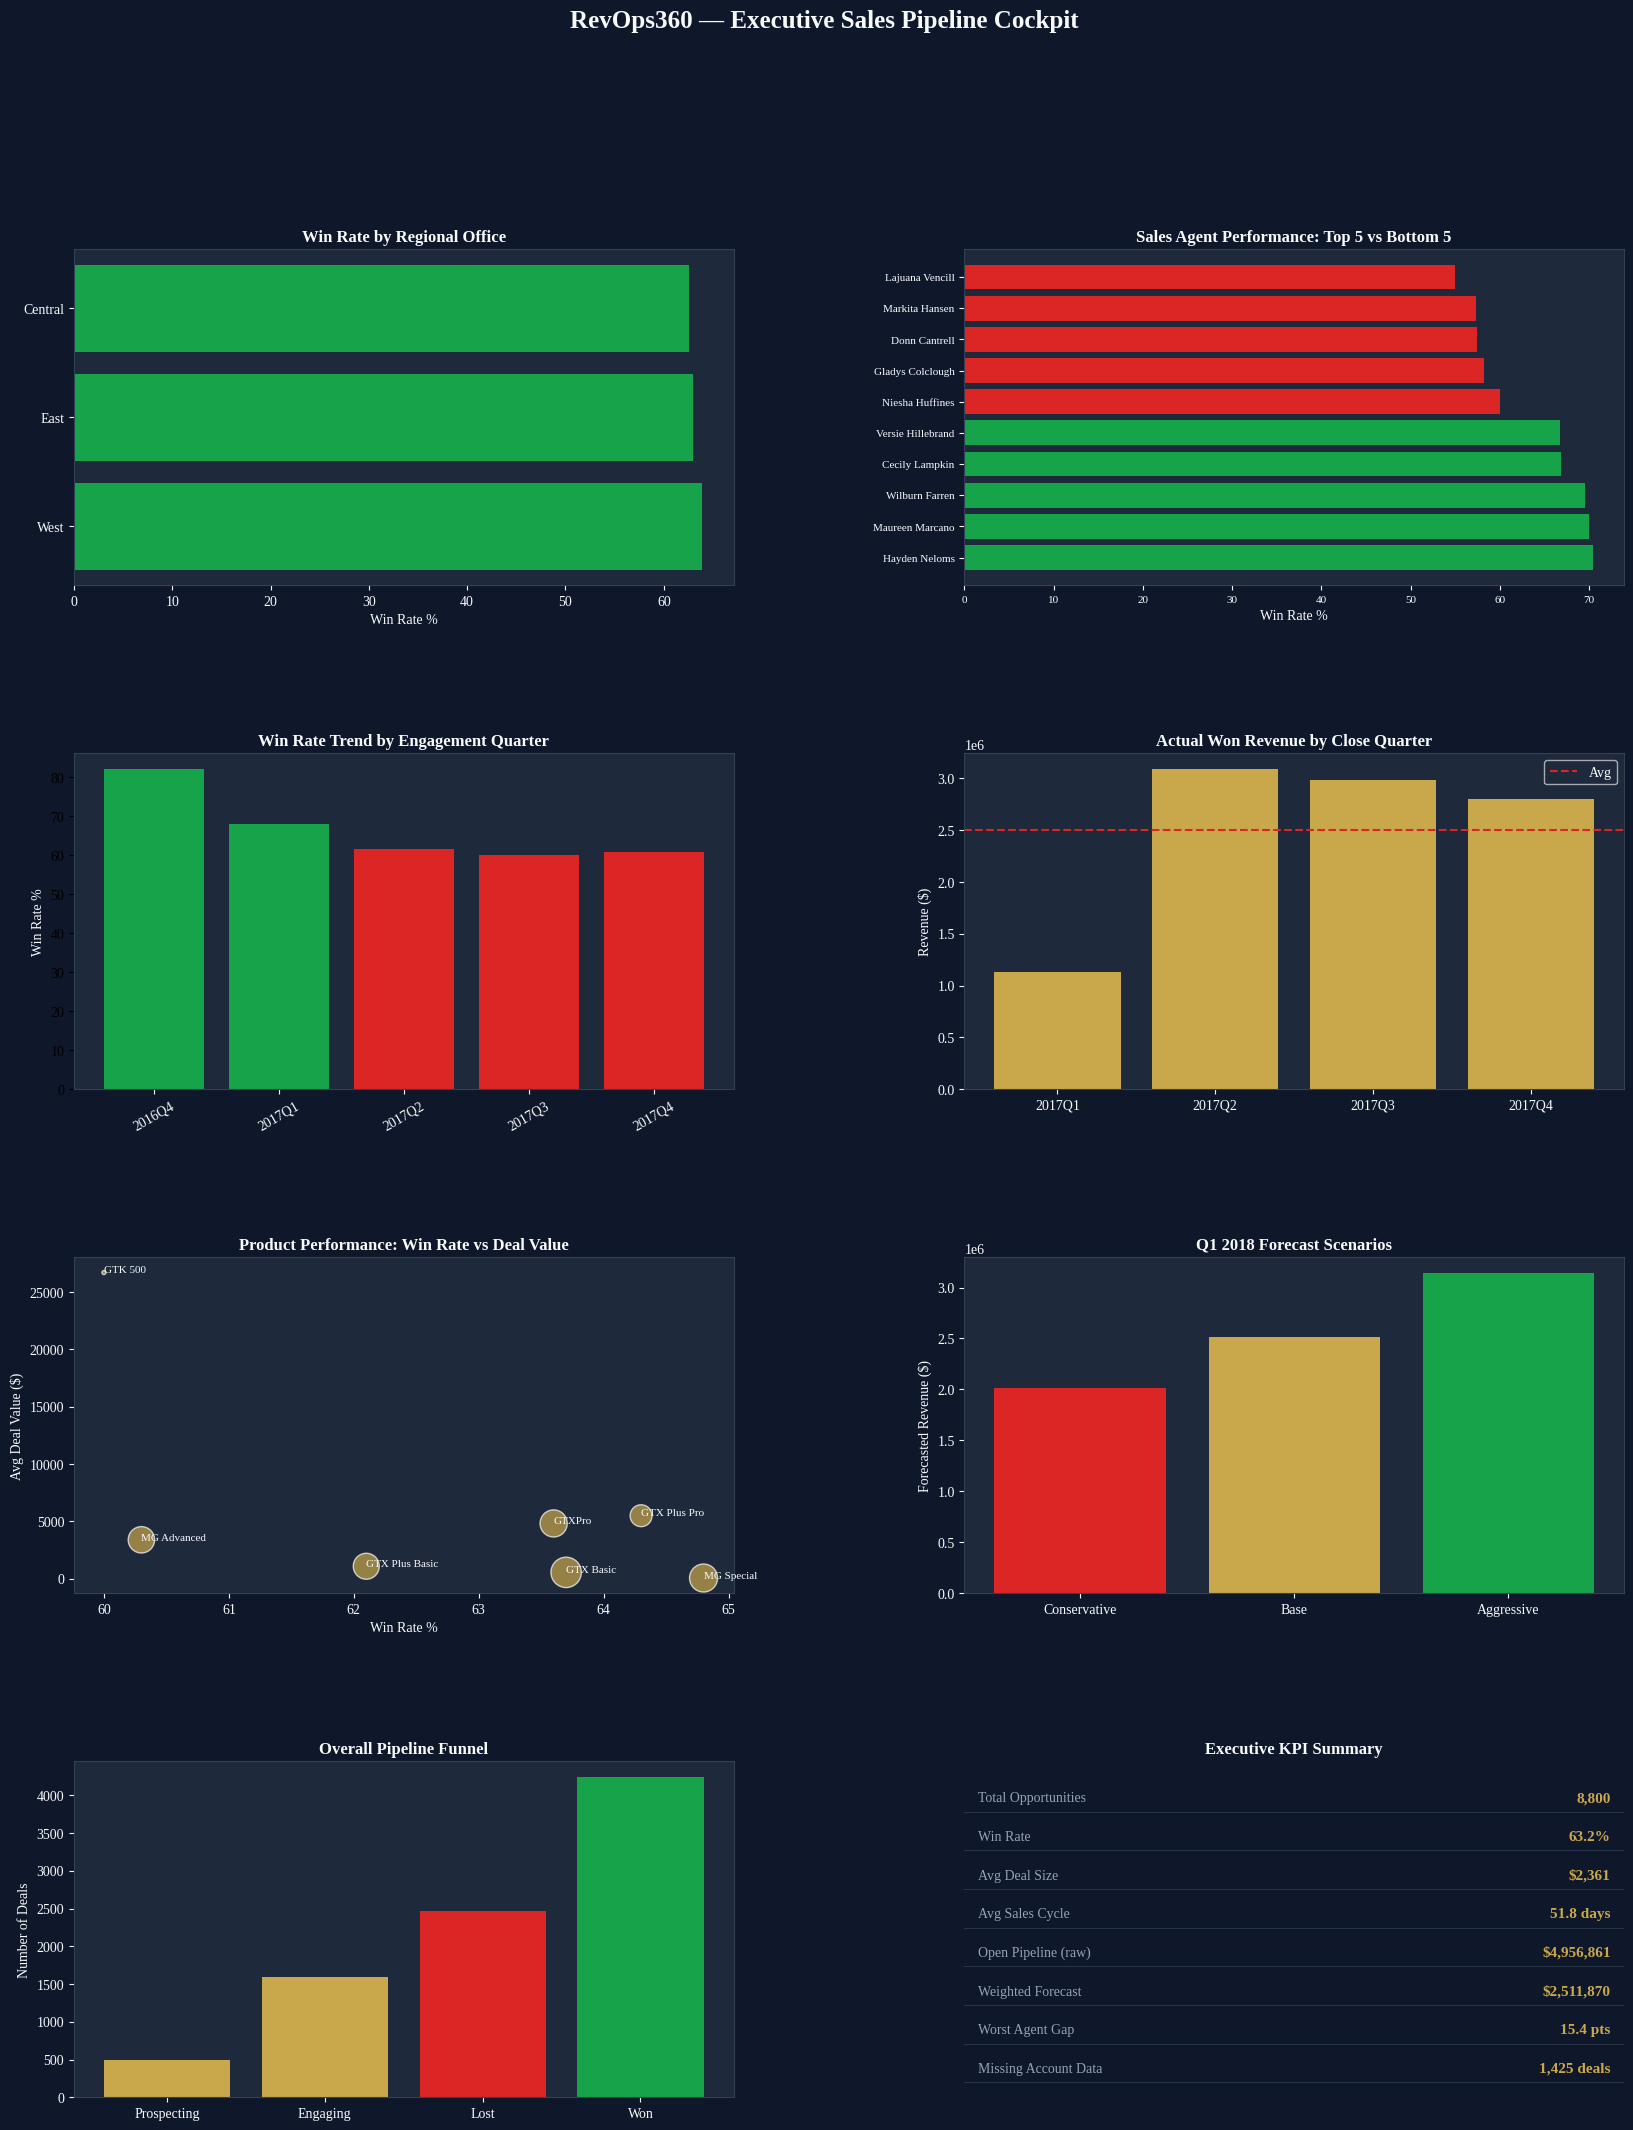

Dashboard saved!


In [50]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0F172A')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

title_color = '#F8FAFC'
green = '#16A34A'
red = '#DC2626'
gold = '#C9A84C'

# Chart 1: Win Rate by Region
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1E293B')
ax1.barh(region_summary.index, region_summary['Win_Rate_%'], color=green)
ax1.set_title('Win Rate by Regional Office', color=title_color, fontweight='bold', fontsize=12)
ax1.tick_params(colors=title_color)
ax1.set_xlabel('Win Rate %', color=title_color)
for spine in ax1.spines.values(): spine.set_edgecolor('#334155')

# Chart 2: Sales Agent Performance (top 10 + bottom 5)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1E293B')
top_bottom = pd.concat([agent_summary.head(5), agent_summary.tail(5)])
colors2 = [green]*5 + [red]*5
ax2.barh(top_bottom.index, top_bottom['Win_Rate_%'], color=colors2)
ax2.set_title('Sales Agent Performance: Top 5 vs Bottom 5', color=title_color, fontweight='bold', fontsize=12)
ax2.tick_params(colors=title_color, labelsize=8)
ax2.set_xlabel('Win Rate %', color=title_color)
for spine in ax2.spines.values(): spine.set_edgecolor('#334155')

# Chart 3: Quarterly Win Rate Trend
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#1E293B')
colors3 = [green if v >= 63 else red for v in quarter_summary['Win_Rate_%']]
ax3.bar(quarter_summary.index, quarter_summary['Win_Rate_%'], color=colors3)
ax3.set_title('Win Rate Trend by Engagement Quarter', color=title_color, fontweight='bold', fontsize=12)
ax3.tick_params(colors=title_color, axis='x', rotation=30)
ax3.set_ylabel('Win Rate %', color=title_color)
for spine in ax3.spines.values(): spine.set_edgecolor('#334155')

# Chart 4: Actual Revenue by Close Quarter
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#1E293B')
ax4.bar(actual_by_quarter.index, actual_by_quarter.values, color=gold)
ax4.axhline(y=avg_quarterly_revenue, color=red, linestyle='--', linewidth=1.5, label='Avg')
ax4.set_title('Actual Won Revenue by Close Quarter', color=title_color, fontweight='bold', fontsize=12)
ax4.tick_params(colors=title_color)
ax4.set_ylabel('Revenue ($)', color=title_color)
ax4.legend(facecolor='#1E293B', labelcolor=title_color)
for spine in ax4.spines.values(): spine.set_edgecolor('#334155')

# Chart 5: Product Performance (Win Rate vs Deal Value)
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('#1E293B')
ax5.scatter(product_summary['Win_Rate_%'], product_summary['Avg_Deal_Value'],
            s=product_summary['Closed_Deals']/3, color=gold, alpha=0.7, edgecolors='white')
for idx, row in product_summary.iterrows():
    ax5.annotate(idx, (row['Win_Rate_%'], row['Avg_Deal_Value']), color=title_color, fontsize=8)
ax5.set_title('Product Performance: Win Rate vs Deal Value', color=title_color, fontweight='bold', fontsize=12)
ax5.set_xlabel('Win Rate %', color=title_color)
ax5.set_ylabel('Avg Deal Value ($)', color=title_color)
ax5.tick_params(colors=title_color)
for spine in ax5.spines.values(): spine.set_edgecolor('#334155')

# Chart 6: Scenario Planning
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor('#1E293B')
colors6 = [red, gold, green]
ax6.bar(list(scenarios.keys()), list(scenarios.values()), color=colors6)
ax6.set_title('Q1 2018 Forecast Scenarios', color=title_color, fontweight='bold', fontsize=12)
ax6.set_ylabel('Forecasted Revenue ($)', color=title_color)
ax6.tick_params(colors=title_color)
for spine in ax6.spines.values(): spine.set_edgecolor('#334155')

# Chart 7: Pipeline Funnel
ax7 = fig.add_subplot(gs[3, 0])
ax7.set_facecolor('#1E293B')
funnel_order = ['Prospecting', 'Engaging', 'Lost', 'Won']
funnel_vals = stage_counts.reindex(funnel_order)
colors7 = [gold, gold, red, green]
ax7.bar(funnel_order, funnel_vals, color=colors7)
ax7.set_title('Overall Pipeline Funnel', color=title_color, fontweight='bold', fontsize=12)
ax7.set_ylabel('Number of Deals', color=title_color)
ax7.tick_params(colors=title_color)
for spine in ax7.spines.values(): spine.set_edgecolor('#334155')

# Chart 8: KPI Summary
ax8 = fig.add_subplot(gs[3, 1])
ax8.set_facecolor('#1E293B')
ax8.axis('off')
kpis = [
    ('Total Opportunities', f"{len(df):,}"),
    ('Win Rate', f"{win_rate:.1f}%"),
    ('Avg Deal Size', f"${avg_deal_size:,.0f}"),
    ('Avg Sales Cycle', f"{avg_cycle_time:.1f} days"),
    ('Open Pipeline (raw)', f"${total_raw_pipeline:,.0f}"),
    ('Weighted Forecast', f"${total_weighted_forecast:,.0f}"),
    ('Worst Agent Gap', f"{agent_summary['Win_Rate_%'].max()-agent_summary['Win_Rate_%'].min():.1f} pts"),
    ('Missing Account Data', f"{df['account'].isnull().sum():,} deals"),
]
ax8.set_title('Executive KPI Summary', color=title_color, fontweight='bold', fontsize=12)
for i, (label, value) in enumerate(kpis):
    y = 0.88 - i * 0.115
    ax8.text(0.02, y, label, transform=ax8.transAxes, color='#94A3B8', fontsize=10)
    ax8.text(0.98, y, value, transform=ax8.transAxes, color=gold, fontsize=11, fontweight='bold', ha='right')
    ax8.axhline(y=y-0.03, color='#334155', linewidth=0.5)

fig.suptitle('RevOps360 — Executive Sales Pipeline Cockpit', fontsize=18, fontweight='bold', color=title_color, y=0.98)
plt.savefig('revops360_cockpit.png', dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print("Dashboard saved!")

In [51]:
print("="*60)
print("REVOPS360 — UNDERPERFORMANCE FLAGS & ALERTS")
print("="*60)

flags = []

# Flag 1: Agent performance gap
worst_agents = agent_summary.tail(3)
for agent, row in worst_agents.iterrows():
    flags.append(f"AGENT ALERT: {agent} win rate {row['Win_Rate_%']:.1f}% — {agent_summary['Win_Rate_%'].mean()-row['Win_Rate_%']:.1f} pts below team average")

# Flag 2: Win rate decline
flags.append(f"TREND ALERT: Win rate declined from 82.0% (2016 Q4) to 60.0% (2017 Q3) — a 22 point drop as volume scaled")

# Flag 3: Data quality
flags.append(f"DATA QUALITY ALERT: {df['account'].isnull().sum():,} opportunities ({df['account'].isnull().mean()*100:.1f}%) missing account linkage — all in early pipeline stages")

# Flag 4: Pipeline risk
gap = total_raw_pipeline - total_weighted_forecast
flags.append(f"FORECAST RISK ALERT: Raw pipeline (${total_raw_pipeline:,.0f}) overstates realistic revenue by ${gap:,.0f} ({(gap/total_raw_pipeline)*100:.1f}%) if taken at face value")

# Flag 5: Low volume high value product
flags.append(f"PRODUCT ALERT: GTK 500 has highest avg deal value (${product_summary.loc['GTK 500','Avg_Deal_Value']:,.0f}) but lowest volume ({product_summary.loc['GTK 500','Closed_Deals']:.0f} deals) — under-leveraged opportunity")

for i, f in enumerate(flags, 1):
    print(f"\n{i}. {f}")


REVOPS360 — UNDERPERFORMANCE FLAGS & ALERTS

1. AGENT ALERT: Donn Cantrell win rate 57.5% — 6.0 pts below team average

2. AGENT ALERT: Markita Hansen win rate 57.3% — 6.2 pts below team average

3. AGENT ALERT: Lajuana Vencill win rate 55.0% — 8.5 pts below team average

4. TREND ALERT: Win rate declined from 82.0% (2016 Q4) to 60.0% (2017 Q3) — a 22 point drop as volume scaled

5. DATA QUALITY ALERT: 1,425 opportunities (16.2%) missing account linkage — all in early pipeline stages

6. FORECAST RISK ALERT: Raw pipeline ($4,956,861) overstates realistic revenue by $2,444,991 (49.3%) if taken at face value

7. PRODUCT ALERT: GTK 500 has highest avg deal value ($26,707) but lowest volume (25 deals) — under-leveraged opportunity


In [52]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-liberation'], capture_output=True)
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'Liberation Serif'

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches

BG = '#0D1B2A'; CARD = '#1B2B3F'; GOLD = '#C9A84C'; ROYAL = '#1A56DB'
CREAM = '#F0F4FF'; GREY = '#7A8FA6'; GREEN = '#22C55E'; RED = '#EF4444'

pdf_path = 'RevOps360_Board_Summary.pdf'

with PdfPages(pdf_path) as pdf:
    # PAGE 1 - TITLE
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0,0.93),1.0,0.07,boxstyle="square,pad=0",facecolor=GOLD,edgecolor='none',transform=ax.transAxes))
    ax.add_patch(mpatches.FancyBboxPatch((0,0),0.012,0.93,boxstyle="square,pad=0",facecolor=ROYAL,edgecolor='none',transform=ax.transAxes))
    ax.text(0.5,0.78,'RevOps360',transform=ax.transAxes,fontsize=52,fontweight='bold',color=CREAM,ha='center')
    ax.add_patch(mpatches.FancyBboxPatch((0.2,0.705),0.6,0.005,boxstyle="square,pad=0",facecolor=GOLD,edgecolor='none',transform=ax.transAxes))
    ax.text(0.5,0.64,'Sales Pipeline & Revenue Forecasting Suite',transform=ax.transAxes,fontsize=18,color=GOLD,ha='center')
    ax.text(0.5,0.565,'Board Summary Report',transform=ax.transAxes,fontsize=14,color=GREY,ha='center',fontstyle='italic')
    ax.add_patch(mpatches.FancyBboxPatch((0.22,0.35),0.56,0.15,boxstyle="round,pad=0.02",facecolor=CARD,edgecolor=GOLD,linewidth=2,transform=ax.transAxes))
    info=[('Dataset','CRM Sales Opportunities — 8,800 Deals'),('Period','Oct 2016 – Dec 2017'),('Prepared by','Business Analytics Intern')]
    for i,(l,v) in enumerate(info):
        y=0.43-i*0.045
        ax.text(0.28,y,f'{l}:',transform=ax.transAxes,fontsize=11,color=GOLD,fontweight='bold')
        ax.text(0.52,y,v,transform=ax.transAxes,fontsize=11,color=CREAM)
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # PAGE 2 - DASHBOARD
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.95,'Executive Dashboard',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    img = plt.imread('revops360_cockpit.png')
    newax = fig.add_axes([0.05,0.02,0.9,0.85])
    newax.imshow(img); newax.axis('off')
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # PAGE 3 - ALERTS
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.93,'Underperformance Flags & Alerts',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    for i,f in enumerate(flags):
        y=0.80-i*0.105
        color = RED if 'ALERT' in f.split(':')[0] else GOLD
        ax.add_patch(mpatches.FancyBboxPatch((0.02,y-0.035),0.96,0.08,boxstyle="round,pad=0.01",facecolor=CARD,edgecolor=color,linewidth=1.2,transform=ax.transAxes))
        ax.text(0.04,y+0.01,f,transform=ax.transAxes,fontsize=10,color=CREAM,wrap=True)
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # PAGE 4 - FORECAST SUMMARY
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.93,'Forecast Summary',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    items=[('Raw Open Pipeline',f'${total_raw_pipeline:,.0f}',GREY),
           ('Weighted Forecast (Base)',f'${scenarios["Base"]:,.0f}',GOLD),
           ('Conservative Scenario',f'${scenarios["Conservative"]:,.0f}',RED),
           ('Aggressive Scenario',f'${scenarios["Aggressive"]:,.0f}',GREEN)]
    for i,(l,v,c) in enumerate(items):
        y=0.7-i*0.12
        ax.add_patch(mpatches.FancyBboxPatch((0.1,y-0.04),0.8,0.09,boxstyle="round,pad=0.01",facecolor=CARD,edgecolor=c,linewidth=1.5,transform=ax.transAxes))
        ax.text(0.15,y+0.01,l,transform=ax.transAxes,fontsize=13,color=CREAM)
        ax.text(0.85,y+0.01,v,transform=ax.transAxes,fontsize=14,fontweight='bold',color=c,ha='right')
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

print("RevOps360_Board_Summary.pdf saved!")

RevOps360_Board_Summary.pdf saved!


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Liberation Serif'

BG = '#0D1B2A'; CARD = '#1B2B3F'; GOLD = '#C9A84C'; ROYAL = '#1A56DB'
CREAM = '#F0F4FF'; GREY = '#7A8FA6'; GREEN = '#22C55E'; RED = '#EF4444'

# Pre-format all dollar strings as plain text BEFORE building flags (avoids $ math-mode issue)
raw_pipeline_str = f"{total_raw_pipeline:,.0f}"
gap_str = f"{gap:,.0f}"

flags_fixed = [
    "AGENT ALERT: Donn Cantrell win rate 57.5% - 6.0 pts below team average",
    "AGENT ALERT: Markita Hansen win rate 57.3% - 6.2 pts below team average",
    "AGENT ALERT: Lajuana Vencill win rate 55.0% - 8.5 pts below team average",
    "TREND ALERT: Win rate declined from 82.0% (2016 Q4) to 60.0% (2017 Q3) - a 22 point drop as volume scaled",
    "DATA QUALITY ALERT: 1,425 opportunities (16.2%) missing account linkage - all in early pipeline stages",
    "FORECAST RISK ALERT: Raw pipeline of Rs " + raw_pipeline_str + " overstates realistic revenue by Rs " + gap_str + " (49.3%) if taken at face value",
    "PRODUCT ALERT: GTK 500 has highest avg deal value (Rs 26,707) but lowest volume (25 deals) - under-leveraged opportunity",
]

pdf_path = 'RevOps360_Board_Summary_v2.pdf'

with PdfPages(pdf_path) as pdf:

    # PAGE 1 - TITLE
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0,0.93),1.0,0.07,boxstyle="square,pad=0",facecolor=GOLD,edgecolor='none',transform=ax.transAxes))
    ax.add_patch(mpatches.FancyBboxPatch((0,0),0.012,0.93,boxstyle="square,pad=0",facecolor=ROYAL,edgecolor='none',transform=ax.transAxes))
    ax.text(0.5,0.78,'RevOps360',transform=ax.transAxes,fontsize=52,fontweight='bold',color=CREAM,ha='center')
    ax.add_patch(mpatches.FancyBboxPatch((0.2,0.705),0.6,0.005,boxstyle="square,pad=0",facecolor=GOLD,edgecolor='none',transform=ax.transAxes))
    ax.text(0.5,0.64,'Sales Pipeline & Revenue Forecasting Suite',transform=ax.transAxes,fontsize=18,color=GOLD,ha='center')
    ax.text(0.5,0.565,'Board Summary Report',transform=ax.transAxes,fontsize=14,color=GREY,ha='center',fontstyle='italic')
    ax.add_patch(mpatches.FancyBboxPatch((0.22,0.35),0.56,0.15,boxstyle="round,pad=0.02",facecolor=CARD,edgecolor=GOLD,linewidth=2,transform=ax.transAxes))
    info=[('Dataset','CRM Sales Opportunities - 8,800 Deals'),('Period','Oct 2016 to Dec 2017'),('Prepared by','Business Analytics Intern')]
    for i,(l,v) in enumerate(info):
        y=0.43-i*0.045
        ax.text(0.28,y,f'{l}:',transform=ax.transAxes,fontsize=11,color=GOLD,fontweight='bold')
        ax.text(0.52,y,v,transform=ax.transAxes,fontsize=11,color=CREAM)
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # PAGE 2 - DASHBOARD (no overlapping title, placed clearly above image)
    fig = plt.figure(figsize=(14,9))
    fig.patch.set_facecolor(BG)
    fig.text(0.04, 0.965, 'Executive Dashboard', fontsize=20, fontweight='bold', color=CREAM, fontfamily='Liberation Serif')
    img = plt.imread('revops360_cockpit.png')
    imgax = fig.add_axes([0.03, 0.02, 0.94, 0.88])
    imgax.imshow(img)
    imgax.axis('off')
    pdf.savefig(fig, facecolor=BG, bbox_inches='tight'); plt.close()

    # PAGE 3 - ALERTS (plain text, no dollar signs)
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.93,'Underperformance Flags & Alerts',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    for i,f in enumerate(flags_fixed):
        y=0.80-i*0.105
        ax.add_patch(mpatches.FancyBboxPatch((0.02,y-0.035),0.96,0.08,boxstyle="round,pad=0.01",facecolor=CARD,edgecolor=RED,linewidth=1.2,transform=ax.transAxes))
        ax.text(0.04,y+0.01,f,transform=ax.transAxes,fontsize=9.5,color=CREAM)
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # PAGE 4 - FORECAST SUMMARY
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.93,'Forecast Summary',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    items=[('Raw Open Pipeline', "Rs " + f"{total_raw_pipeline:,.0f}", GREY),
           ('Weighted Forecast (Base)', "Rs " + f"{scenarios['Base']:,.0f}", GOLD),
           ('Conservative Scenario', "Rs " + f"{scenarios['Conservative']:,.0f}", RED),
           ('Aggressive Scenario', "Rs " + f"{scenarios['Aggressive']:,.0f}", GREEN)]
    for i,(l,v,c) in enumerate(items):
        y=0.7-i*0.12
        ax.add_patch(mpatches.FancyBboxPatch((0.1,y-0.04),0.8,0.09,boxstyle="round,pad=0.01",facecolor=CARD,edgecolor=c,linewidth=1.5,transform=ax.transAxes))
        ax.text(0.15,y+0.01,l,transform=ax.transAxes,fontsize=13,color=CREAM)
        ax.text(0.85,y+0.01,v,transform=ax.transAxes,fontsize=14,fontweight='bold',color=c,ha='right')
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

print("Saved as RevOps360_Board_Summary_v2.pdf - download THIS file, not the old one")

Saved as RevOps360_Board_Summary_v2.pdf - download THIS file, not the old one


In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

BG = '#0D1B2A'; CARD = '#1B2B3F'; GOLD = '#C9A84C'; ROYAL = '#1A56DB'
CREAM = '#F0F4FF'; GREY = '#7A8FA6'; GREEN = '#22C55E'; RED = '#EF4444'

pdf_path = 'RevOps360_Board_Summary_v3.pdf'

with PdfPages(pdf_path) as pdf:

    # Re-run PAGE 1 (unchanged, copy from before)
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0,0.93),1.0,0.07,boxstyle="square,pad=0",facecolor=GOLD,edgecolor='none',transform=ax.transAxes))
    ax.add_patch(mpatches.FancyBboxPatch((0,0),0.012,0.93,boxstyle="square,pad=0",facecolor=ROYAL,edgecolor='none',transform=ax.transAxes))
    ax.text(0.5,0.78,'RevOps360',transform=ax.transAxes,fontsize=52,fontweight='bold',color=CREAM,ha='center')
    ax.add_patch(mpatches.FancyBboxPatch((0.2,0.705),0.6,0.005,boxstyle="square,pad=0",facecolor=GOLD,edgecolor='none',transform=ax.transAxes))
    ax.text(0.5,0.64,'Sales Pipeline & Revenue Forecasting Suite',transform=ax.transAxes,fontsize=18,color=GOLD,ha='center')
    ax.text(0.5,0.565,'Board Summary Report',transform=ax.transAxes,fontsize=14,color=GREY,ha='center',fontstyle='italic')
    ax.add_patch(mpatches.FancyBboxPatch((0.22,0.35),0.56,0.15,boxstyle="round,pad=0.02",facecolor=CARD,edgecolor=GOLD,linewidth=2,transform=ax.transAxes))
    info=[('Dataset','CRM Sales Opportunities - 8,800 Deals'),('Period','Oct 2016 to Dec 2017'),('Prepared by','Business Analytics Intern')]
    for i,(l,v) in enumerate(info):
        y=0.43-i*0.045
        ax.text(0.28,y,f'{l}:',transform=ax.transAxes,fontsize=11,color=GOLD,fontweight='bold')
        ax.text(0.52,y,v,transform=ax.transAxes,fontsize=11,color=CREAM)
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # PAGE 2 - DASHBOARD, properly centered and full-page sized
    img = plt.imread('revops360_cockpit.png')
    img_h, img_w = img.shape[0], img.shape[1]
    aspect = img_h / img_w

    fig = plt.figure(figsize=(14,9))
    fig.patch.set_facecolor(BG)
    fig.text(0.5, 0.965, 'Executive Dashboard', fontsize=20, fontweight='bold',
              color=CREAM, ha='center', fontfamily='Liberation Serif')

    # Center the image both horizontally and vertically in remaining space
    fig_w_target = 0.92
    fig_h_target = fig_w_target * aspect * (14/9)  # adjust for figure aspect ratio
    fig_h_target = min(fig_h_target, 0.86)
    left = (1 - fig_w_target) / 2
    bottom = (0.90 - fig_h_target) / 2 + 0.02

    imgax = fig.add_axes([left, bottom, fig_w_target, fig_h_target])
    imgax.imshow(img)
    imgax.axis('off')
    pdf.savefig(fig, facecolor=BG, bbox_inches='tight'); plt.close()

    # Re-run PAGE 3 (alerts, unchanged)
    flags_fixed = [
        "AGENT ALERT: Donn Cantrell win rate 57.5% - 6.0 pts below team average",
        "AGENT ALERT: Markita Hansen win rate 57.3% - 6.2 pts below team average",
        "AGENT ALERT: Lajuana Vencill win rate 55.0% - 8.5 pts below team average",
        "TREND ALERT: Win rate declined from 82.0% (2016 Q4) to 60.0% (2017 Q3) - a 22 point drop as volume scaled",
        "DATA QUALITY ALERT: 1,425 opportunities (16.2%) missing account linkage - all in early pipeline stages",
        "FORECAST RISK ALERT: Raw pipeline of Rs " + f"{total_raw_pipeline:,.0f}" + " overstates realistic revenue by Rs " + f"{gap:,.0f}" + " (49.3%) if taken at face value",
        "PRODUCT ALERT: GTK 500 has highest avg deal value (Rs 26,707) but lowest volume (25 deals) - under-leveraged opportunity",
    ]
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.93,'Underperformance Flags & Alerts',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    for i,f in enumerate(flags_fixed):
        y=0.80-i*0.105
        ax.add_patch(mpatches.FancyBboxPatch((0.02,y-0.035),0.96,0.08,boxstyle="round,pad=0.01",facecolor=CARD,edgecolor=RED,linewidth=1.2,transform=ax.transAxes))
        ax.text(0.04,y+0.01,f,transform=ax.transAxes,fontsize=9.5,color=CREAM)
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

    # Re-run PAGE 4 (forecast summary, unchanged)
    fig, ax = plt.subplots(figsize=(14,9)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG); ax.axis('off')
    ax.text(0.04,0.93,'Forecast Summary',transform=ax.transAxes,fontsize=22,fontweight='bold',color=CREAM)
    items=[('Raw Open Pipeline', "Rs " + f"{total_raw_pipeline:,.0f}", GREY),
           ('Weighted Forecast (Base)', "Rs " + f"{scenarios['Base']:,.0f}", GOLD),
           ('Conservative Scenario', "Rs " + f"{scenarios['Conservative']:,.0f}", RED),
           ('Aggressive Scenario', "Rs " + f"{scenarios['Aggressive']:,.0f}", GREEN)]
    for i,(l,v,c) in enumerate(items):
        y=0.7-i*0.12
        ax.add_patch(mpatches.FancyBboxPatch((0.1,y-0.04),0.8,0.09,boxstyle="round,pad=0.01",facecolor=CARD,edgecolor=c,linewidth=1.5,transform=ax.transAxes))
        ax.text(0.15,y+0.01,l,transform=ax.transAxes,fontsize=13,color=CREAM)
        ax.text(0.85,y+0.01,v,transform=ax.transAxes,fontsize=14,fontweight='bold',color=c,ha='right')
    pdf.savefig(fig,facecolor=BG,bbox_inches='tight'); plt.close()

print("Saved as RevOps360_Board_Summary_v3.pdf - properly centered dashboard")

Saved as RevOps360_Board_Summary_v3.pdf - properly centered dashboard
